# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [20]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs
from IPython.display import display

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "rho0.30_p500_n100_k10"

In [21]:
#==============================================================================================
# Data Loading: Import the simulated data sets from corresponding folders
#==============================================================================================

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(5):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_test.csv")
    )

print("Shape of Training Data: ", np.shape(df_train[0]))
df_train[0].head()

Shape of Training Data:  (50, 500)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x491,x492,x493,x494,x495,x496,x497,x498,x499,x500
0,-1.284847,0.117143,0.966956,0.692332,0.920784,0.117096,1.227485,1.984335,0.755079,-0.212088,...,1.197928,-1.330981,2.189786,-0.207774,2.153587,1.605488,1.687805,-1.888008,-0.599674,0.116393
1,-0.172687,0.786646,-1.122340,1.224381,-1.016780,-0.186908,-0.443761,-0.463288,-0.427635,0.573872,...,2.812416,-1.577247,-0.116131,-0.979602,-0.321114,0.460600,0.034768,0.696059,0.513468,1.287315
2,-0.129190,0.623939,-0.318017,-1.852352,1.316915,-0.365800,0.535887,-0.287672,1.292286,-0.054853,...,-0.768193,-0.022604,-1.001953,0.219604,-0.440727,1.949530,-1.732175,-0.417661,-0.111366,0.832644
3,-1.355802,-1.447653,1.256059,-0.617829,-0.906838,1.668865,-0.000830,-0.121969,0.073313,0.302942,...,-0.370061,-0.139847,0.192246,-0.425939,0.408584,0.041009,-1.005185,1.255266,-1.740930,-1.476925
4,1.015654,2.007175,-1.144208,0.503575,-1.600653,-1.169424,1.375541,1.672493,-0.855568,-1.557350,...,-0.211546,0.187599,0.665383,-1.650357,0.731843,-0.276952,0.277627,-0.852319,3.140413,0.646353


In [22]:
#==============================================================================================
# Parameter Setting: Set the rank parameter and the seed of the script for reproducibility
#==============================================================================================

## set the seed
random.seed(1)

## set the basis parameters
k = 10

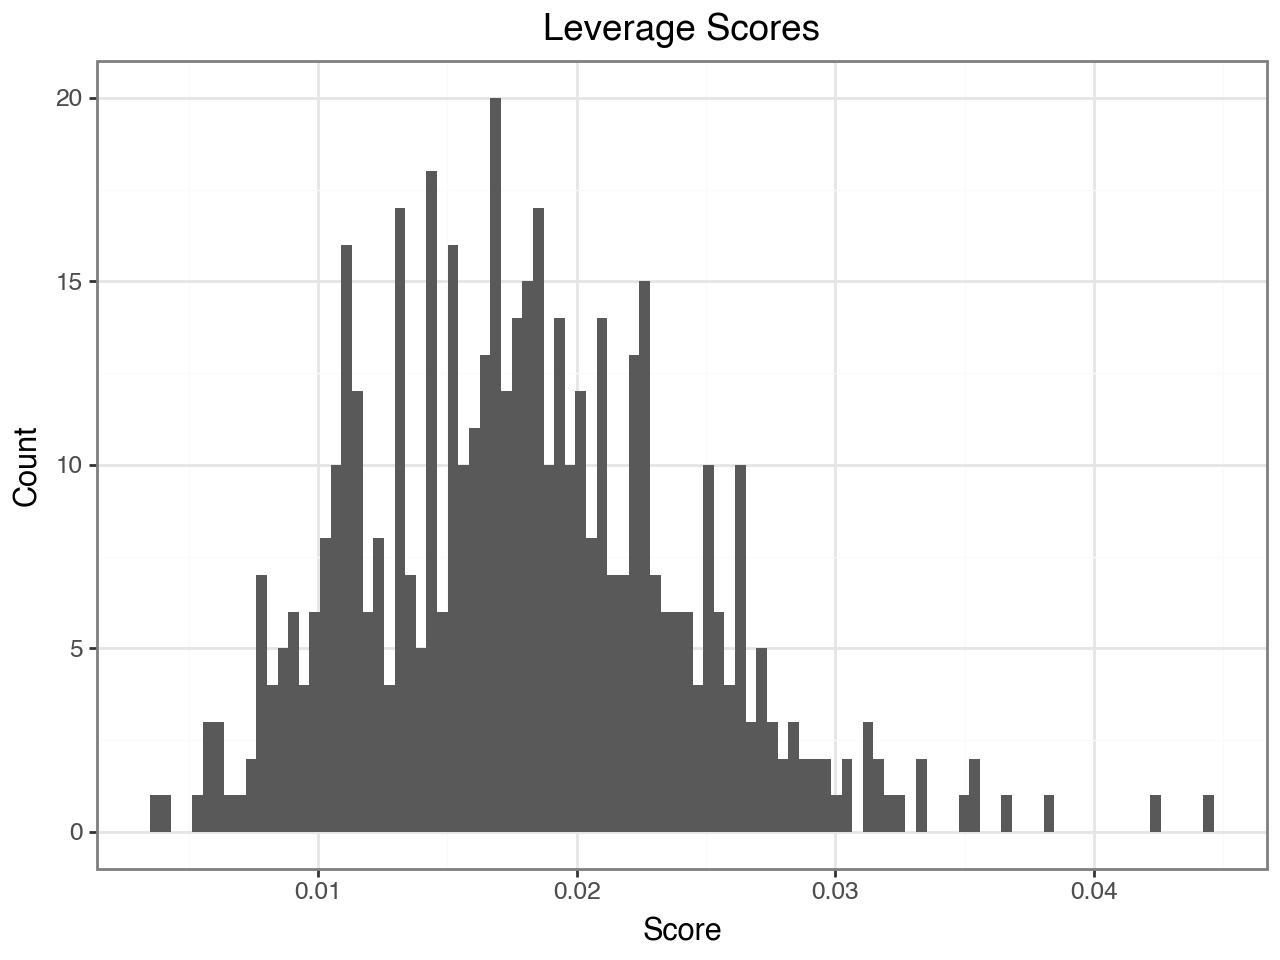

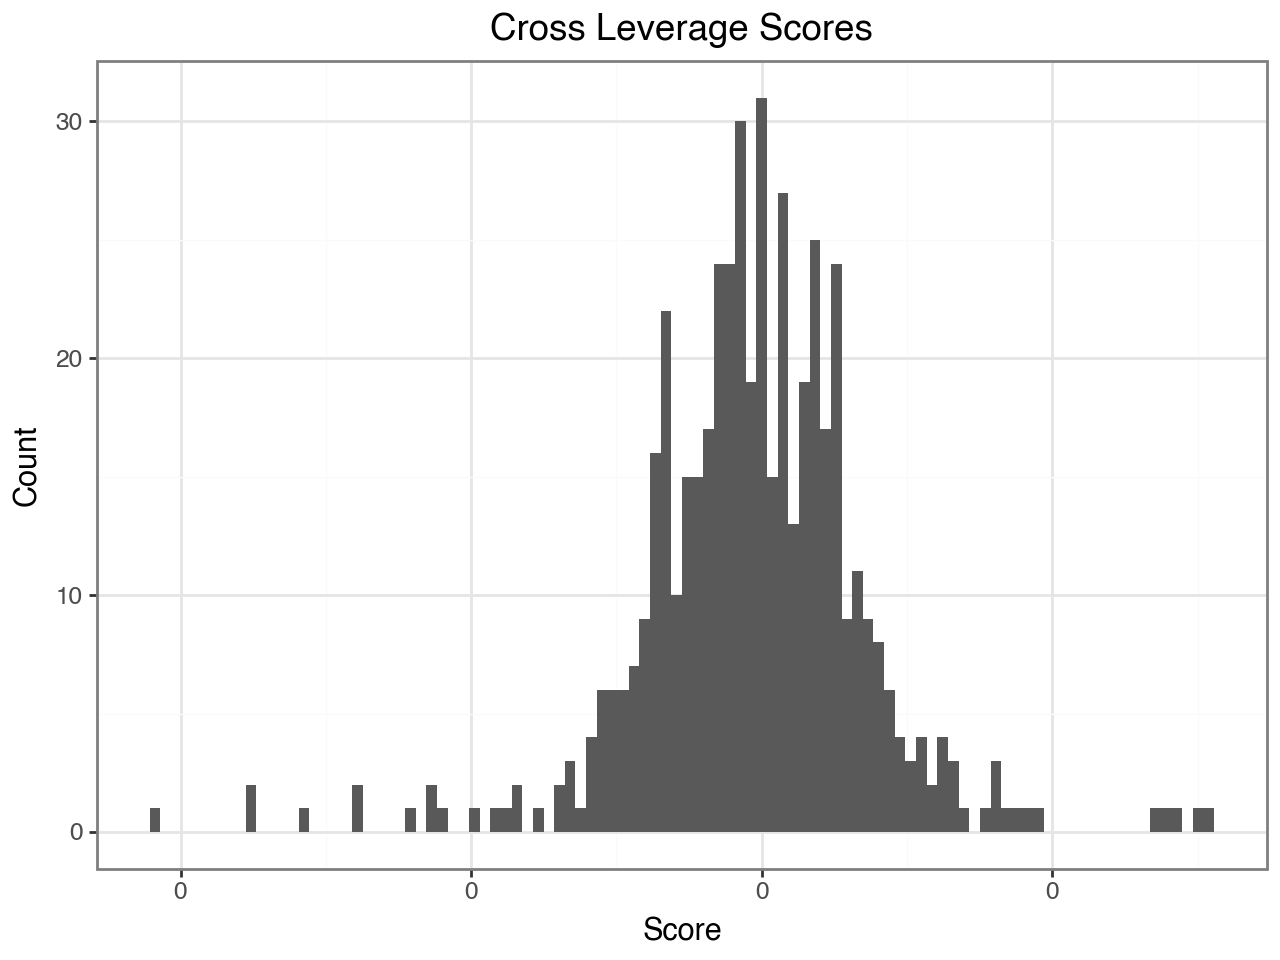

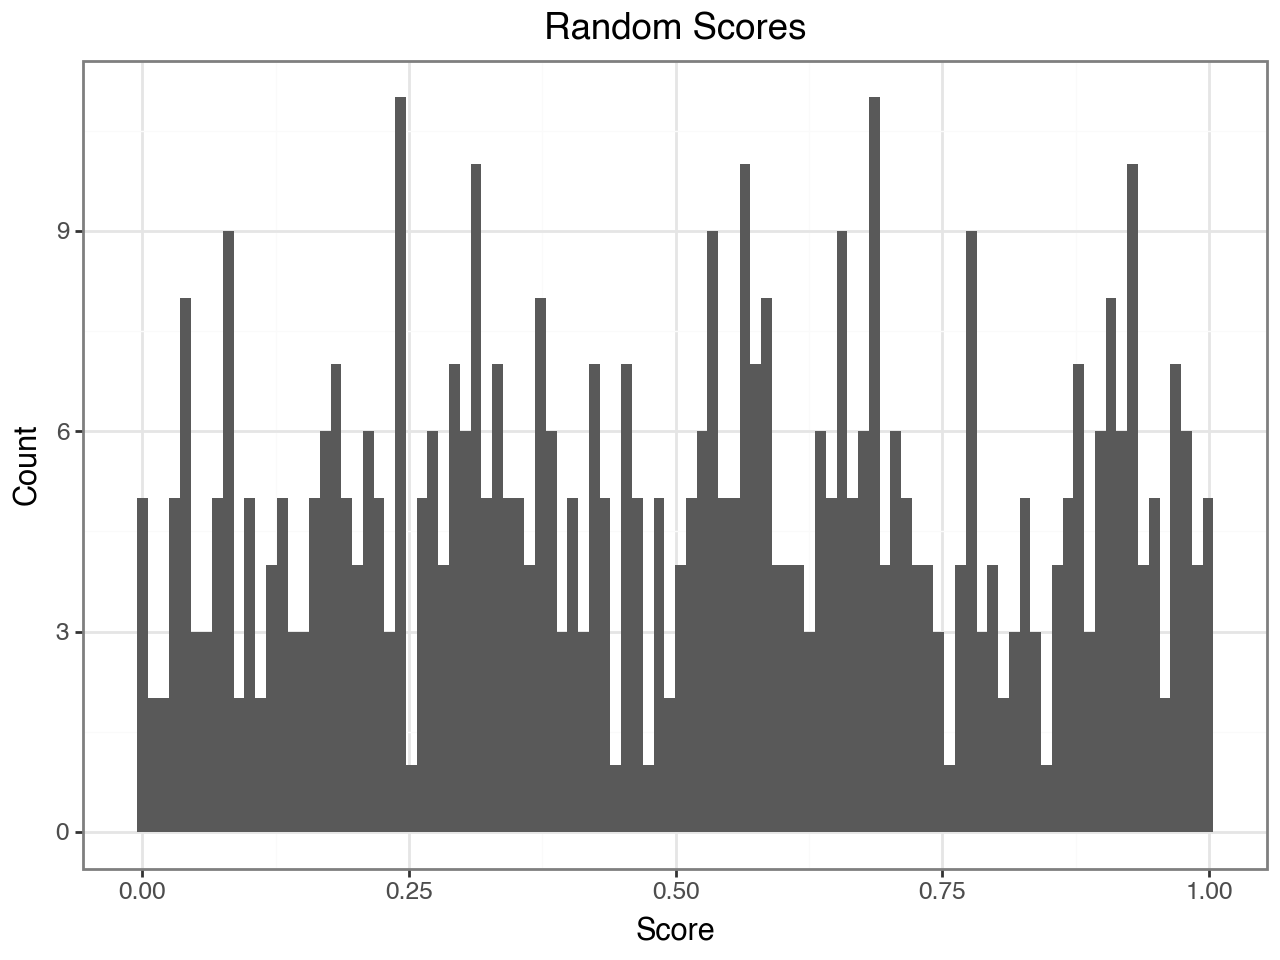

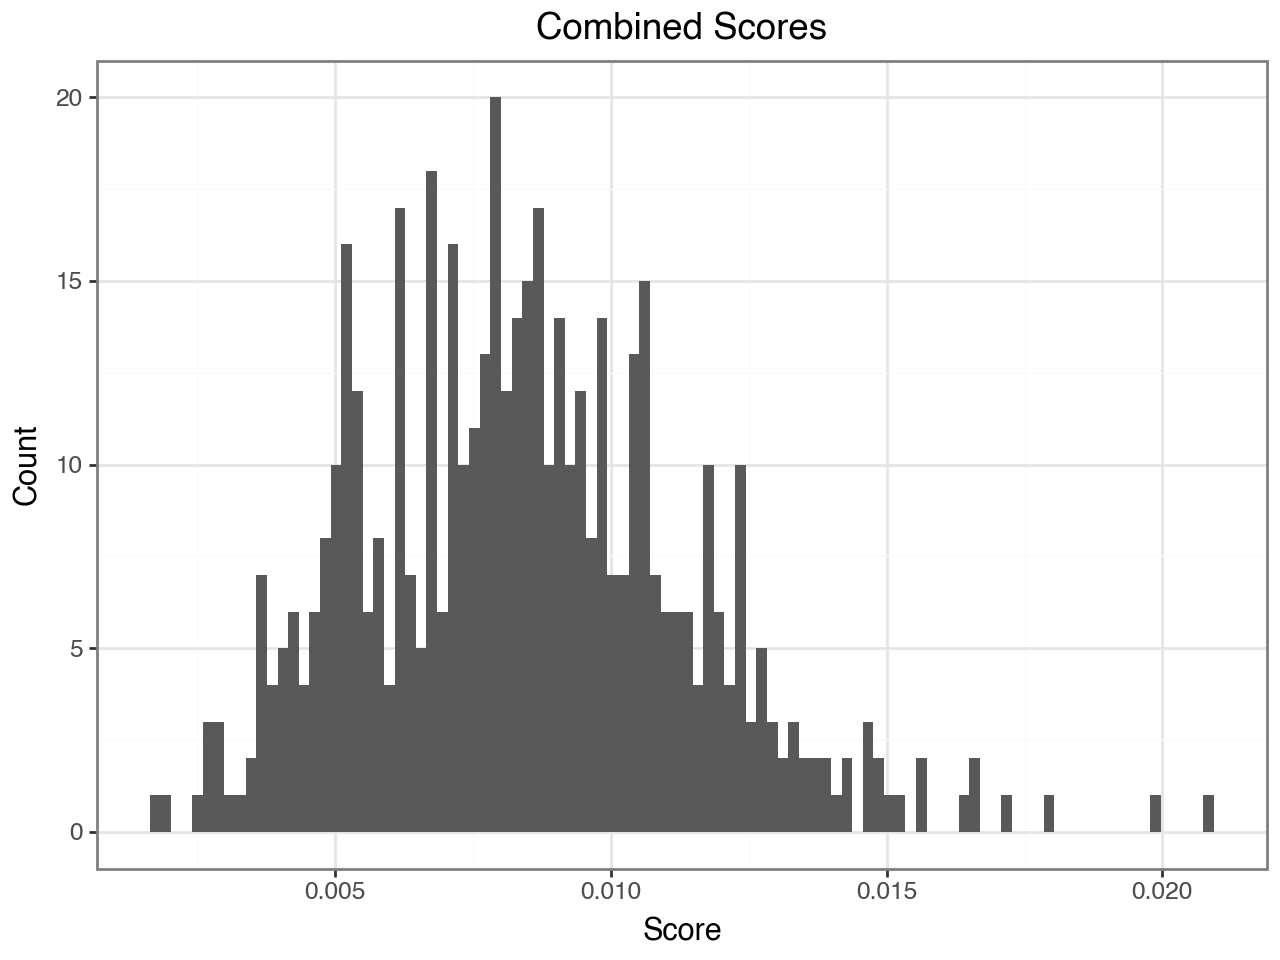

In [23]:
#==============================================================================================
# Scoring Mechanisms: Application of different scoring functions to the training data
#==============================================================================================

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(5):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
df_ls  = pd.DataFrame({'value': column_ls[0]})
df_cls = pd.DataFrame({'value': column_cls[0]})
df_rs  = pd.DataFrame({'value': column_rs[0]})
df_cs  = pd.DataFrame({'value': column_cs[0]})

display(
    ggplot(df_ls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_cls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Cross Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_rs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Random Scores', x='Score', y='Count')
)

display(
    ggplot(df_cs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Combined Scores', x='Score', y='Count')
)

In [24]:
#==============================================================================================
# Column Reduction: Application of column reduction mechanism
#==============================================================================================

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(5):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], column_cls[i], k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

In [25]:
#==============================================================================================
# Row Reduction: Application of row reduction mechanism
#==============================================================================================

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(5):
    R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
    R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
    R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
    R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))

TypeError: row_reduction() takes 2 positional arguments but 3 were given

In [18]:
#==============================================================================================
# Linear Modeling: Application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

## Fit linear models to the reduced data matrix
model_ls = []
model_cls = []
model_rs = []
model_cs = []
for i in range(5):
    model = LinearRegression()
    model.fit(R_ls[i]['R'], R_ls[i]['y'])
    model_ls.append(model)
    model = LinearRegression()
    model.fit(R_cls[i]['R'], R_cls[i]['y'])
    model_cls.append(model)
    model = LinearRegression()
    model.fit(R_rs[i]['R'], R_rs[i]['y'])
    model_rs.append(model)
    model = LinearRegression()
    model.fit(R_cs[i]['R'], R_cs[i]['y'])
    model_cs.append(model)

## Build predictions
predictions_ls = []
predictions_cls = []
predictions_rs = []
predictions_cs = []
df_test_reduced_ls = []
df_test_reduced_cls = []
df_test_reduced_rs = []
df_test_reduced_cs = []
for i in range(5):
    df_test_reduced_ls.append(df_test[i].iloc[:, C_ls[i]['selected_columns']])
    predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
    df_test_reduced_cls.append(df_test[i].iloc[:, C_cls[i]['selected_columns']])
    predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
    df_test_reduced_rs.append(df_test[i].iloc[:, C_rs[i]['selected_columns']])
    predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
    df_test_reduced_cs.append(df_test[i].iloc[:, C_cs[i]['selected_columns']])
    predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

## Calculate RMSE
rmse_ls = []
rmse_cls = []
rmse_rs = []
rmse_cs = []
for i in range(1):
    print("LS",i)
    rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
    print("CLS",i)
    rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
    print("RS",i)
    rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
    print("CS",i)
    rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))

KeyError: 'y'